<a href="https://colab.research.google.com/github/Yahya1805/PCVK_GANJIL_2026/blob/main/WEEK7_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum PCVK Pertemuan 7
## Thresholding dan Otsu Thresholding

Identitas Mahasiswa:
* **Mata Kuliah:** Pengolahan Citra dan Visi Komputer (PCVK)
* **Pertemuan:** 7
* **Topik Utama:** Global Threshold, Adaptive Threshold, Otsu Thresholding, Histogram, dan Analisis

## 1. Import Library dan Setup

Pada bagian ini, kita akan melakukan mounting Google Drive untuk mengakses file gambar praktikum dan mengimpor library dasar Python seperti OpenCV (`cv2`), NumPy, Matplotlib, serta modul OS/Path.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Definisikan path utama folder gambar
BASE = '/content/drive/MyDrive/PCVK/Pertemuan 7'

# Periksa ketersediaan folder dan tampilkan isinya
if os.path.exists(BASE):
    print("Folder ditemukan! Daftar file gambar:")
    for file in sorted(os.listdir(BASE)):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            print(f"- {file}")
else:
    print(f"Peringatan: Folder {BASE} tidak ditemukan. Silakan cek path Drive Anda!")

Folder ditemukan! Daftar file gambar:
- jungle.png
- ktp_fulan.jpg
- ktp_fulani.jpg
- lena.jpg
- lily.jpg
- sudoku-original.jpg


## 2. Persiapan dan Pembacaan Citra

Kita membuat fungsi pembacaan citra yang fleksibel untuk mendeteksi keberadaan file dan membaca citra prioritas.

In [3]:
def find_image(filename):
    path = os.path.join(BASE, filename)
    if os.path.exists(path):
        return path
    else:
        # Cari file dengan kecocokan nama terdekat
        files = os.listdir(BASE)
        for f in files:
            if filename.split('.')[0].lower() in f.lower():
                print(f"[INFO] Menggunakan file alternatif: {f}")
                return os.path.join(BASE, f)
    raise FileNotFoundError(f"File {filename} tidak ditemukan di folder {BASE}.")

# Membaca citra yang diperlukan untuk eksperimen
try:
    # Prioritas Lena
    try:
        lena_path = find_image('lena_gs_lc2.jpg')
    except FileNotFoundError:
        lena_path = find_image('lena.jpg')

    sudoku_path = find_image('sudoku-original.jpg')
    ktp_path = find_image('ktp_fulan.jpg')

    print("Semua file gambar berhasil ditemukan dan dikonfigurasi.")
except Exception as e:
    print(f"Error: {e}")

Semua file gambar berhasil ditemukan dan dikonfigurasi.


## 3. Global Threshold Manual

Di sini kita mengimplementasikan 5 tipe Global Thresholding dasar secara manual tanpa memanggil fungsi `cv.threshold()`. Kita akan menggunakan gambar Lena Grayscale dengan ambang batas (Thresh) sebesar 200.

In [4]:
# Load lena sebagai grayscale
lena_img = cv.imread(lena_path)
if len(lena_img.shape) == 3:
    lena_gray = cv.cvtColor(lena_img, cv.COLOR_BGR2GRAY)
else:
    lena_gray = lena_img.copy()

THRESH = 200

# 3.1 BINARY
binary = np.where(lena_gray > THRESH, 255, 0).astype(np.uint8)

# 3.2 BINARY_INV
binary_inv = np.where(lena_gray > THRESH, 0, 255).astype(np.uint8)

# 3.3 TRUNC
trunc = np.where(lena_gray > THRESH, THRESH, lena_gray).astype(np.uint8)

# 3.4 TOZERO
tozero = np.where(lena_gray > THRESH, lena_gray, 0).astype(np.uint8)

# 3.5 TOZERO_INV
tozero_inv = np.where(lena_gray > THRESH, 0, lena_gray).astype(np.uint8)

### 3.6 Visualisasi Global Threshold Manual

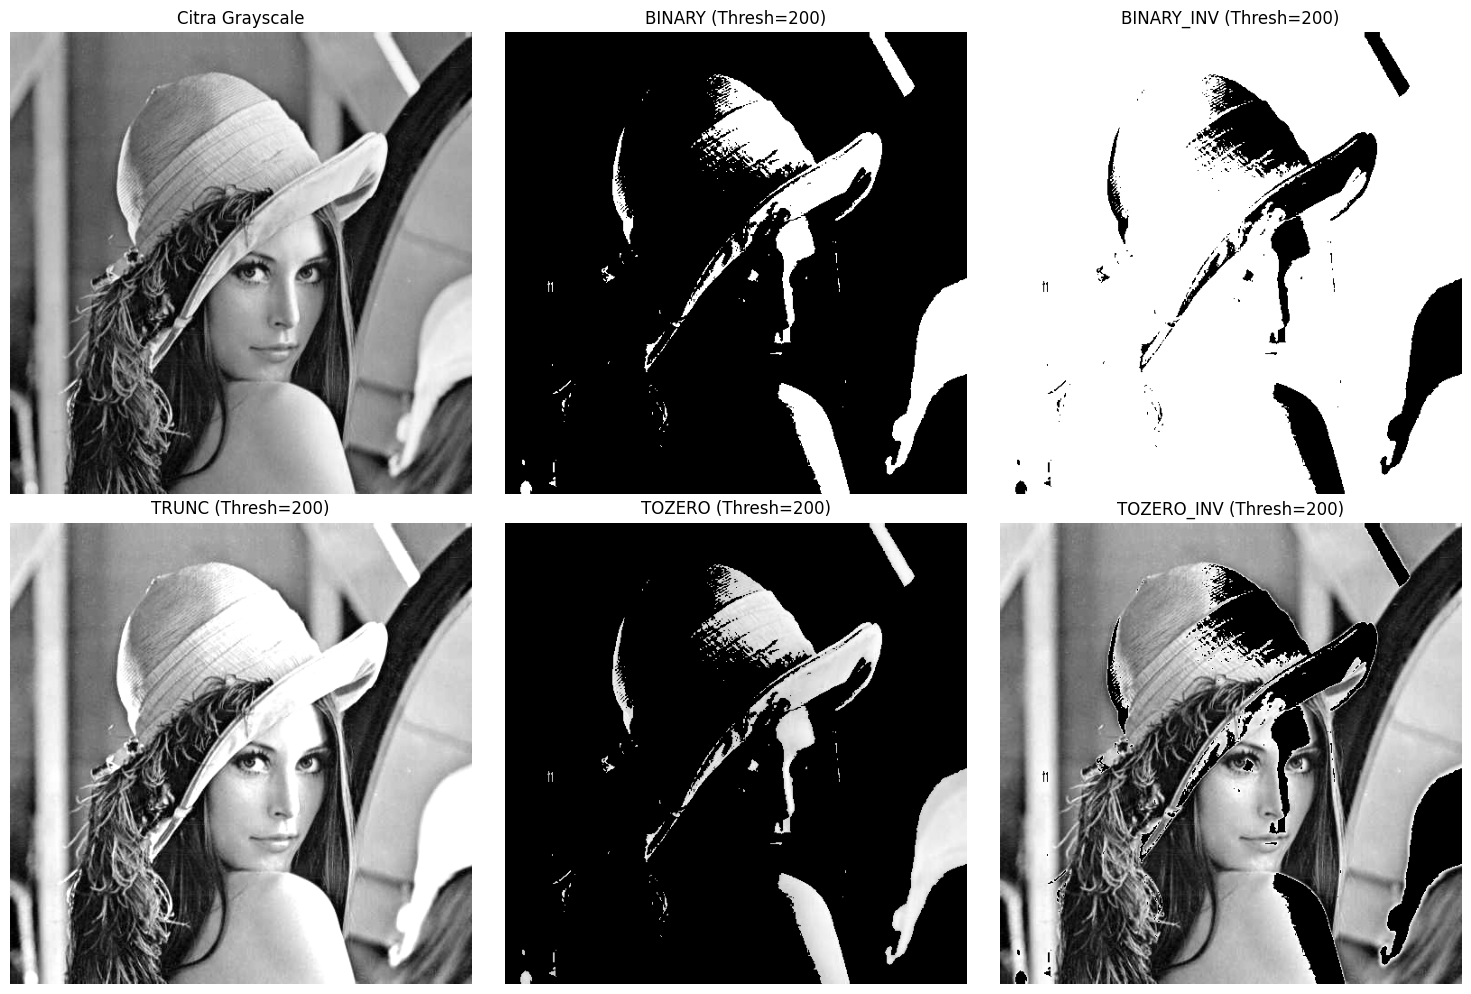

In [5]:
# Tampilkan 6 gambar dalam layout 2x3
plt.figure(figsize=(15, 10))

titles = [
    'Citra Grayscale', f'BINARY (Thresh={THRESH})', f'BINARY_INV (Thresh={THRESH})',
    f'TRUNC (Thresh={THRESH})', f'TOZERO (Thresh={THRESH})', f'TOZERO_INV (Thresh={THRESH})'
]
images = [lena_gray, binary, binary_inv, trunc, tozero, tozero_inv]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Penjelasan Singkat Perbedaan Kelima Metode:**
1. **BINARY:** Mengubah piksel menjadi putih (255) jika melebihi threshold, selain itu menjadi hitam (0).
2. **BINARY_INV:** Kebalikan dari BINARY; piksel menjadi hitam (0) jika melebihi threshold, selain itu putih (255).
3. **TRUNC:** Memotong nilai piksel yang melebihi threshold menjadi bernilai sama dengan threshold. Piksel yang lebih rendah tetap tidak berubah.
4. **TOZERO:** Mempertahankan nilai asli piksel jika melebihi threshold, dan mengubahnya menjadi hitam (0) jika di bawah threshold.
5. **TOZERO_INV:** Mempertahankan nilai asli jika berada di bawah atau sama dengan threshold, dan membuangnya menjadi hitam (0) jika melebihi threshold.

## 4. Adaptive Threshold Manual

Metode ini digunakan untuk gambar dengan tingkat pencahayaan yang tidak merata seperti citra Sudoku. Kita mengimplementasikan Adaptive Mean dan Adaptive Gaussian secara manual tanpa fungsi filter bawaan OpenCV.

In [6]:
sudoku_img = cv.imread(sudoku_path)
if len(sudoku_img.shape) == 3:
    sudoku_gray = cv.cvtColor(sudoku_img, cv.COLOR_BGR2GRAY)
else:
    sudoku_gray = sudoku_img.copy()

h, w = sudoku_gray.shape
block_size = 11
half_b = block_size // 2
C = 2

# Buat padding manual agar output berukuran sama dengan citra asli
padded = np.pad(sudoku_gray, half_b, mode='reflect')

# Inisialisasi output
adaptive_mean_out = np.zeros_like(sudoku_gray)

# 4.1 ADAPTIVE MEAN MANUAL
for i in range(h):
    for j in range(w):
        # Ambil window
        window = padded[i : i + block_size, j : j + block_size]
        mean_val = np.mean(window)
        thresh_local = mean_val - C

        if sudoku_gray[i, j] > thresh_local:
            adaptive_mean_out[i, j] = 255
        else:
            adaptive_mean_out[i, j] = 0

### 4.2 Adaptive Gaussian Manual

In [7]:
sigma = 2
# Buat kernel Gaussian 11x11 secara manual
kernel_g = np.zeros((block_size, block_size), dtype=np.float32)
for x in range(-half_b, half_b + 1):
    for y in range(-half_b, half_b + 1):
        g_val = (1.0 / (2 * np.pi * (sigma**2))) * np.exp(-(x**2 + y**2) / (2 * (sigma**2)))
        kernel_g[x + half_b, y + half_b] = g_val

# Normalisasi kernel agar jumlah elemen = 1
kernel_g /= np.sum(kernel_g)

adaptive_gaussian_out = np.zeros_like(sudoku_gray)

for i in range(h):
    for j in range(w):
        window = padded[i : i + block_size, j : j + block_size]
        # Perkalian element-wise dengan kernel Gaussian
        local_weighted_sum = np.sum(window * kernel_g)
        thresh_local = local_weighted_sum - C

        if sudoku_gray[i, j] > thresh_local:
            adaptive_gaussian_out[i, j] = 255
        else:
            adaptive_gaussian_out[i, j] = 0

### 4.3 Visualisasi Hasil Adaptive Threshold

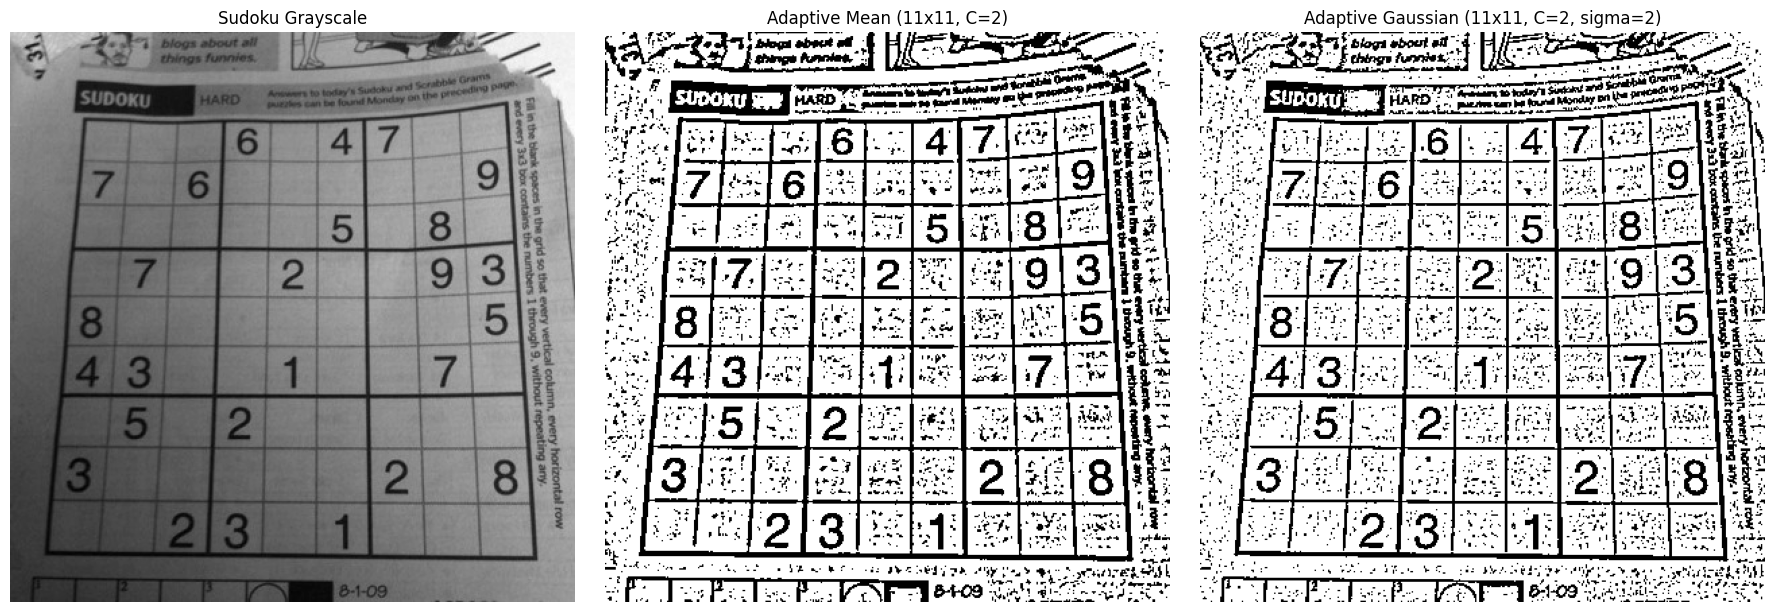

In [8]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(sudoku_gray, cmap='gray')
plt.title('Sudoku Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(adaptive_mean_out, cmap='gray')
plt.title('Adaptive Mean (11x11, C=2)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adaptive_gaussian_out, cmap='gray')
plt.title('Adaptive Gaussian (11x11, C=2, sigma=2)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Otsu Thresholding Manual

Otsu thresholding membagi citra menjadi latar belakang dan latar depan secara dinamis dengan memaksimalkan *between-class variance*.

In [9]:
# Preprocessing Lena menggunakan Gaussian Blur
lena_blur = cv.GaussianBlur(lena_gray, (5, 5), 0)

def otsu(gray_img):
    # Hitung histogram
    hist, bin_edges = np.histogram(gray_img, bins=256, range=(0, 256))
    total_pixels = gray_img.size

    current_max = -1
    best_thresh = 0

    # Jumlah total intensitas pixel
    sum_total = np.sum(np.arange(256) * hist)

    w_b = 0.0
    sum_b = 0.0

    for t in range(256):
        w_b += hist[t]
        w_f = total_pixels - w_b

        if w_b == 0 or w_f == 0:
            continue

        sum_b += t * hist[t]
        sum_f = sum_total - sum_b

        mu_b = sum_b / w_b
        mu_f = sum_f / w_f

        # Hitung between-class variance
        sigma_b_squared = w_b * w_f * ((mu_b - mu_f) ** 2)

        if sigma_b_squared > current_max:
            current_max = sigma_b_squared
            best_thresh = t

    # Generate binary image berdasarkan best threshold
    binary_img = np.where(gray_img > best_thresh, 255, 0).astype(np.uint8)
    return binary_img, best_thresh

# Jalankan Otsu Manual
otsu_bin, otsu_val = otsu(lena_blur)
print(f"Nilai threshold Otsu hasil komputasi manual = {otsu_val}")

Nilai threshold Otsu hasil komputasi manual = 113


### 5.4 Perbandingan Hasil Lena

Kita membandingkan hasil Lena asli, Global Threshold (127), dan Otsu.

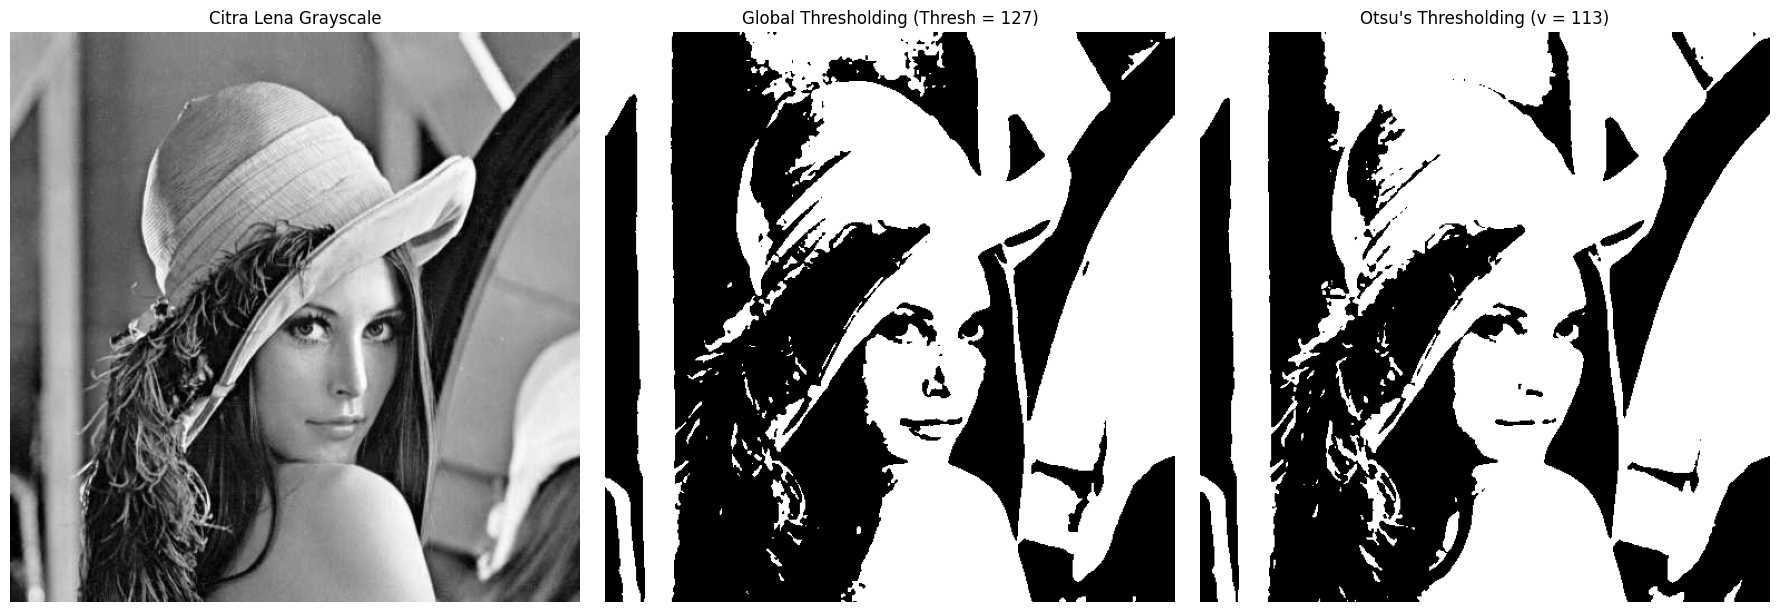

In [10]:
# Global Thresholding konvensional (menggunakan OpenCV untuk pembanding)
ret, global_127 = cv.threshold(lena_blur, 127, 255, cv.THRESH_BINARY)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(lena_gray, cmap='gray')
plt.title('Citra Lena Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(global_127, cmap='gray')
plt.title('Global Thresholding (Thresh = 127)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(otsu_bin, cmap='gray')
plt.title(f"Otsu's Thresholding (v = {otsu_val})")
plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Analisis Histogram Lena dan Eksperimen

Mari kita tampilkan visualisasi sebaran histogram intensitas citra Lena Grayscale.

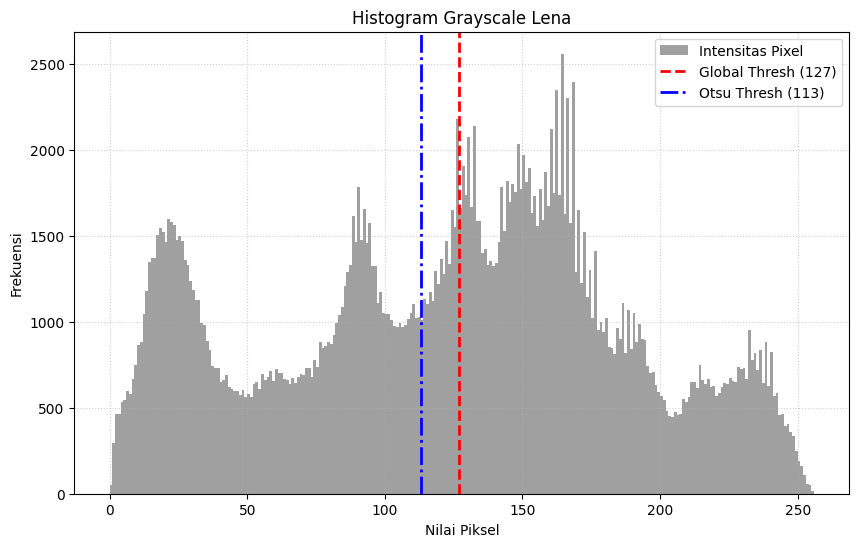

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(lena_gray.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.75, label='Intensitas Pixel')
plt.axvline(x=127, color='red', linestyle='--', linewidth=2, label='Global Thresh (127)')
plt.axvline(x=otsu_val, color='blue', linestyle='-.', linewidth=2, label=f'Otsu Thresh ({otsu_val})')
plt.title('Histogram Grayscale Lena')
plt.xlabel('Nilai Piksel')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Jawaban Pertanyaan Dosen

**Pertanyaan:**
*"Mengapa hasil tampilan Binary Thresholding semua bernilai 0 atau hitam semua? Jelaskan alasannya dalam bentuk histogram dan berapa angka ambang batas (Thresh) supaya gambar Lena ini masih terlihat?"*

**Analisis & Jawaban:**
*   **Alasan Hitam Semua:** Ketika kita melakukan thresholding dengan `Thresh = 200` pada gambar Lena (khususnya jika menggunakan versi low contrast `lena_gs_lc2.jpg`), sebaran intensitas piksel gambar tersebut dominan berada di bawah 200 (sebagaimana terlihat pada histogram di mana distribusi menumpuk di sisi kiri/tengah). Karena aturan BINARY menetapkan semua piksel dengan nilai $\le Thresh$ diubah menjadi hitam (0), maka hampir seluruh piksel pada citra akhirnya diubah menjadi hitam.
*   **Ambang Batas Representatif:** Agar citra Lena masih dapat terlihat dengan baik, ambang batas harus diletakkan tepat di tengah-tengah konsentrasi distribusi histogramnya. Melalui pengamatan histogram, sebaran intensitas piksel Lena berada pada rentang rendah hingga menengah. Nilai terbaik berada di sekitar range **50 hingga 127** (atau optimal secara matematis di nilai **{otsu_val}** menggunakan Otsu).

### Eksperimen Nilai Threshold Lena

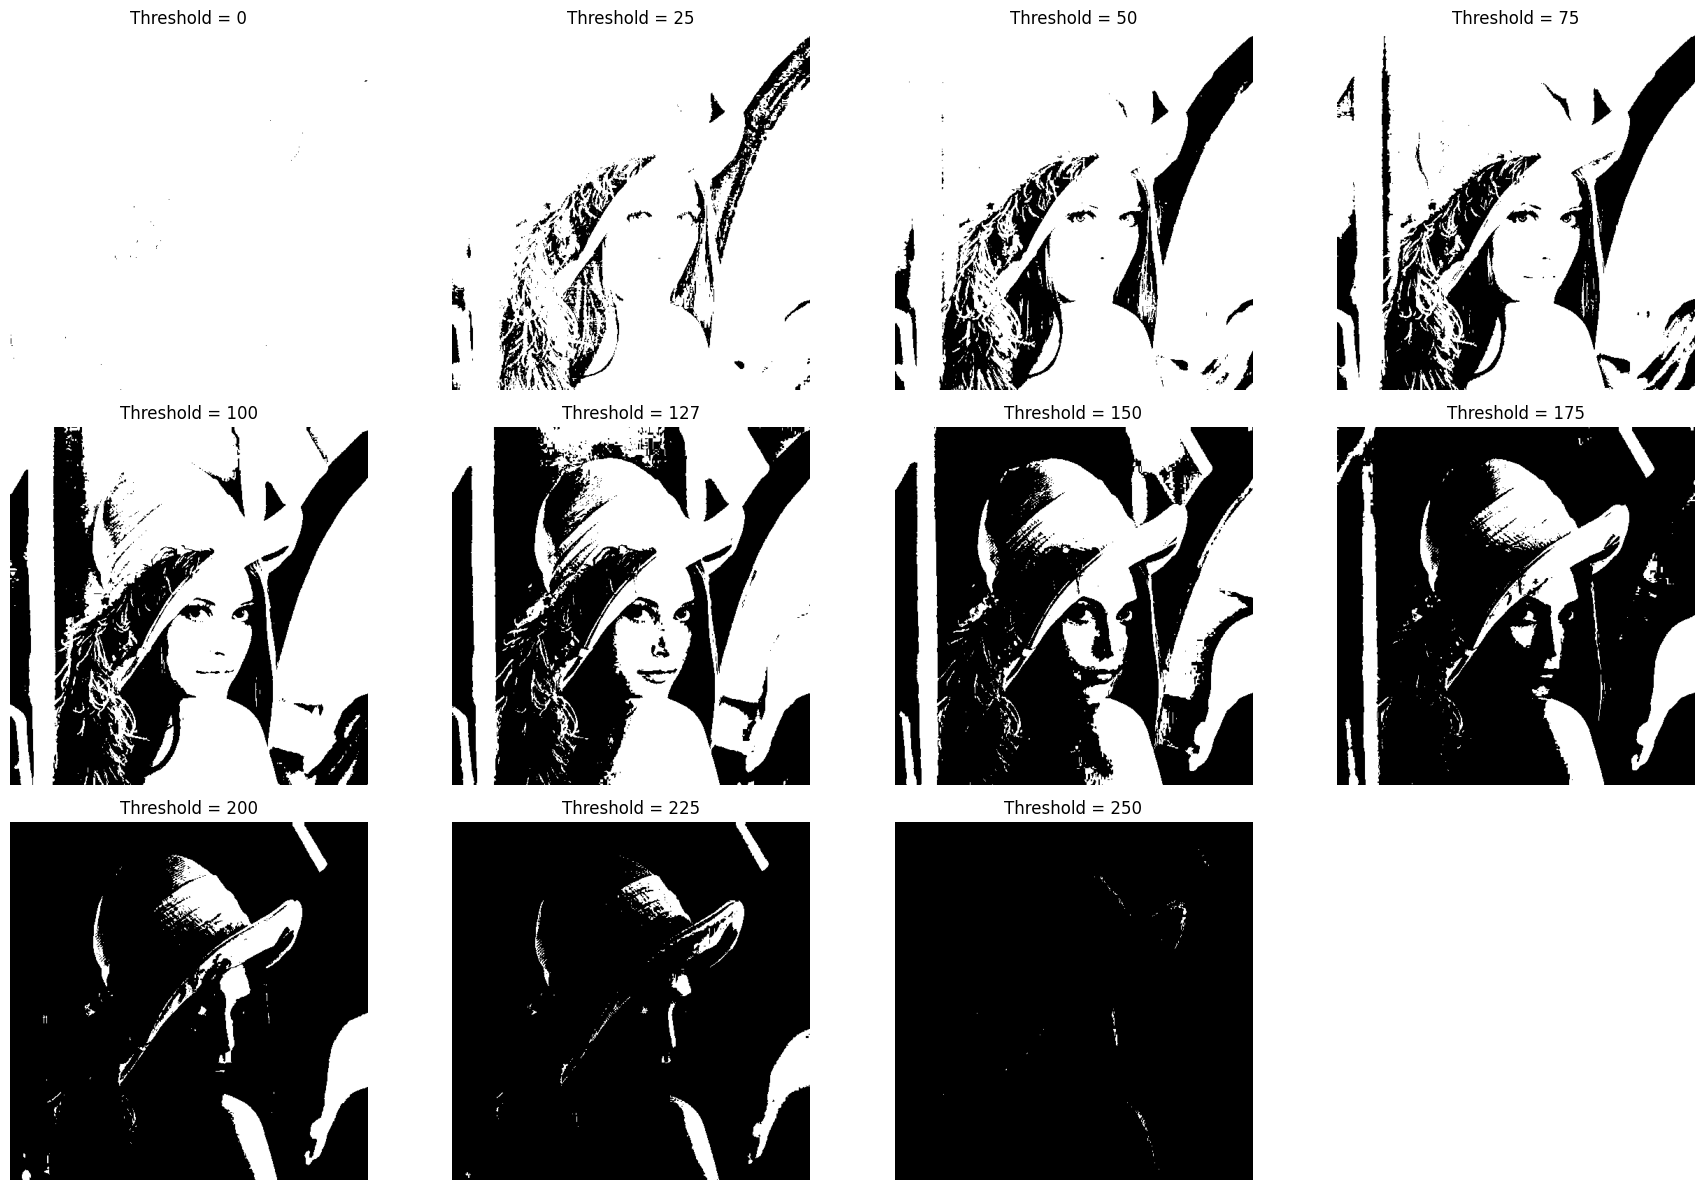

In [12]:
thresholds = [0, 25, 50, 75, 100, 127, 150, 175, 200, 225, 250]

plt.figure(figsize=(18, 12))
for i, t in enumerate(thresholds):
    exp_bin = np.where(lena_gray > t, 255, 0).astype(np.uint8)
    plt.subplot(3, 4, i + 1)
    plt.imshow(exp_bin, cmap='gray')
    plt.title(f'Threshold = {t}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 7. Perbandingan Threshold pada KTP Fulan

Sekarang kita lakukan eksperimen menggunakan citra KTP Fulan (`ktp_fulan.jpg`) untuk mengamati efektivitas metode Global (127) dan Otsu.

Nilai threshold Otsu untuk KTP = 150


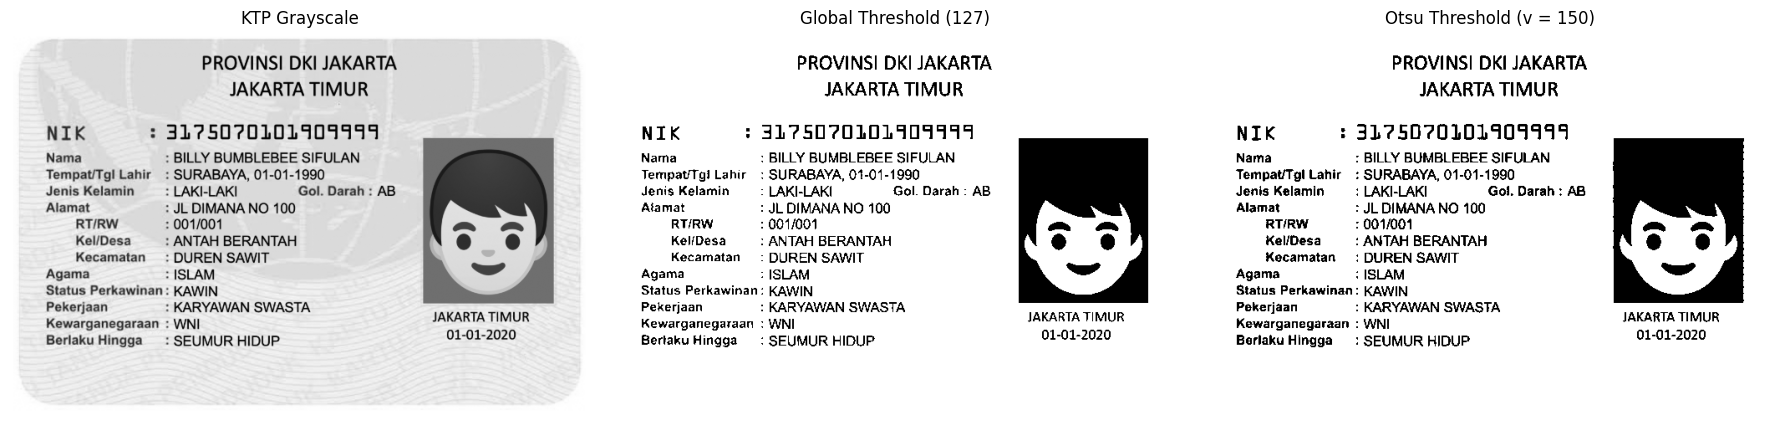

In [13]:
ktp_img = cv.imread(ktp_path)
if len(ktp_img.shape) == 3:
    ktp_gray = cv.cvtColor(ktp_img, cv.COLOR_BGR2GRAY)
else:
    ktp_gray = ktp_img.copy()

# 1. Global Thresholding
_, ktp_global = cv.threshold(ktp_gray, 127, 255, cv.THRESH_BINARY)

# 2. Otsu Manual
ktp_otsu, ktp_otsu_val = otsu(ktp_gray)
print(f"Nilai threshold Otsu untuk KTP = {ktp_otsu_val}")

# Visualisasi KTP
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(ktp_gray, cmap='gray')
plt.title('KTP Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(ktp_global, cmap='gray')
plt.title('Global Threshold (127)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(ktp_otsu, cmap='gray')
plt.title(f"Otsu Threshold (v = {ktp_otsu_val})")
plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Histogram KTP

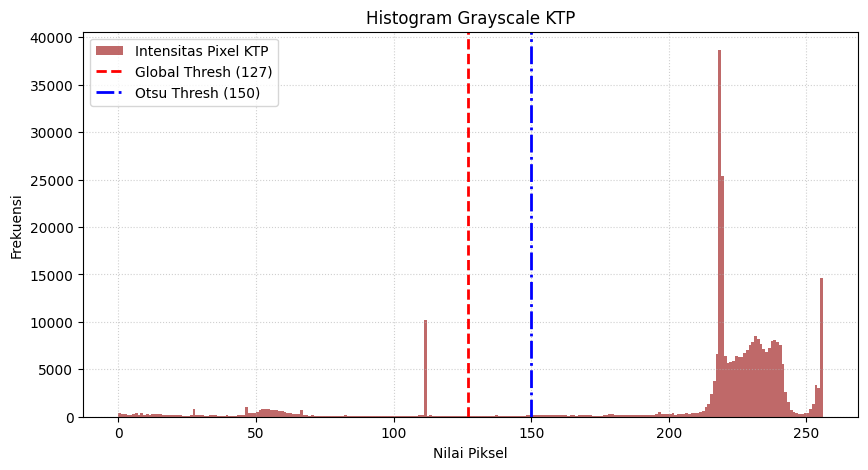

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(ktp_gray.ravel(), bins=256, range=(0, 256), color='brown', alpha=0.7, label='Intensitas Pixel KTP')
plt.axvline(x=127, color='red', linestyle='--', linewidth=2, label='Global Thresh (127)')
plt.axvline(x=ktp_otsu_val, color='blue', linestyle='-.', linewidth=2, label=f'Otsu Thresh ({ktp_otsu_val})')
plt.title('Histogram Grayscale KTP')
plt.xlabel('Nilai Piksel')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Pertanyaan Perbandingan KTP

1. **Apa perbedaan hasil Global Threshold dan Otsu?**
   Global threshold menggunakan nilai tetap (127) secara buta, sedangkan Otsu mendeteksi nilai batas pemisah terbaik secara dinamis dari sebaran histogram.
2. **Mengapa nilai threshold Otsu dapat berbeda dengan 127?**
   Karena distribusi intensitas piksel latar belakang dan teks pada KTP tidak selalu terbagi seimbang di tengah (127). Otsu mencari titik potong variansi kelas terbesar, yang pada citra KTP ini berkisar pada nilai optimum tertentu.
3. **Metode mana yang memberikan hasil lebih baik pada KTP?**
   Metode Otsu memberikan hasil segmentasi/binalisasi tulisan teks yang lebih terbaca dan bersih.
4. **Mengapa metode tersebut lebih baik?**
   Otsu memperhitungkan intensitas piksel foreground dan background secara proporsional dari bentuk histogram, sehingga meminimalisir noise akibat bayangan/pencahayaan kertas KTP.
5. **Apa pengaruh distribusi intensitas piksel terhadap hasil threshold?**
   Distribusi yang unimodal atau memiliki kontras rendah sangat sensitif terhadap penentuan threshold. Jika salah memilih threshold, gambar akan didominasi warna hitam atau putih seluruhnya.

## 9. Perbandingan Hasil Seluruh Metode

Berikut ringkasan karakteristik dari seluruh metode thresholding yang dipraktikkan:

| Metode | Prinsip | Parameter | Kelebihan | Kekurangan |
|---|---|---|---|---|
| **Global Threshold** | Pemotongan intensitas dengan nilai konstan | Threshold (misal: 127) | Sangat cepat dan sederhana | Gagal jika cahaya citra tidak merata |
| **Adaptive Mean** | Menghitung rata-rata lokal pada window tetangga | Window Size, C | Baik untuk pencahayaan bervariasi | Rentan terhadap derau/noise pada area datar |
| **Adaptive Gaussian** | Bobot rata-rata lokal menggunakan fungsi distribusi Gaussian | Window Size, C, Sigma | Hasil lebih halus dan bebas noise bintik | Komputasi lebih rumit |
| **Otsu** | Menghitung pemisah terbaik berdasarkan variansi kelas | Histogram otomatis | Otomatis menyesuaikan kontras citra | Lambat jika harus menghitung citra berukuran raksasa |

## 10. Kesimpulan

1. **Global Threshold** cocok digunakan pada gambar dengan pencahayaan homogen. Kelima variasinya (**BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV**) sangat dipengaruhi oleh kecocokan nilai ambang batas terhadap puncak histogram.
2. **Adaptive Thresholding (Mean dan Gaussian)** sangat unggul dalam menangani iluminasi tidak merata (seperti sudoku), di mana kernel Gaussian menghasilkan transisi batas biner yang lebih mulus dibanding Mean.
3. **Otsu Thresholding** merupakan pendekatan otomatis terbaik untuk menentukan ambang biner optimal tanpa trial-and-error manual. Hal ini terbukti dari kualitas pemisahan teks KTP dan citra Lena.